In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import zipfile, os
from matplotlib.pyplot import savefig

from matplotlib import MatplotlibDeprecationWarning

ZIP_PATH = "OlistData.zip"
DATA_DIR = os.path.join("data", "raw")
os.makedirs(DATA_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(DATA_DIR)

print("Descomprimido en:", DATA_DIR)
print(os.listdir(DATA_DIR)[:20])

warnings.filterwarnings("ignore", category=MatplotlibDeprecationWarning)


Descomprimido en: data\raw
['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']


In [2]:
customers = pd.read_csv(os.path.join(DATA_DIR, "olist_customers_dataset.csv"))
orders = pd.read_csv(os.path.join(DATA_DIR, "olist_orders_dataset.csv"))
items = pd.read_csv(os.path.join(DATA_DIR, "olist_order_items_dataset.csv"))
payments = pd.read_csv(os.path.join(DATA_DIR, "olist_order_payments_dataset.csv"))
reviews = pd.read_csv(os.path.join(DATA_DIR, "olist_order_reviews_dataset.csv"))

for c in [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "order_approved_at",
    "order_delivered_carrier_date",
]:
    if c in orders.columns:
        orders[c] = pd.to_datetime(orders[c], errors="coerce")

customers.head(), orders.head()


(                        customer_id                customer_unique_id  \
 0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
 1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
 2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
 3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
 4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   
 
    customer_zip_code_prefix          customer_city customer_state  
 0                     14409                 franca             SP  
 1                      9790  sao bernardo do campo             SP  
 2                      1151              sao paulo             SP  
 3                      8775        mogi das cruzes             SP  
 4                     13056               campinas             SP  ,
                            order_id                       customer_id  \
 0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10

In [3]:
orders_c = orders.merge(customers, on="customer_id", how="left")

order_value = items.groupby("order_id", as_index=False).agg(
    price_sum=("price", "sum"),
    freight_sum=("freight_value", "sum"),
    n_items=("order_item_id", "count")
)
order_value["order_total"] = order_value["price_sum"] + order_value["freight_sum"]

pay_agg = payments.groupby("order_id", as_index=False).agg(
    pay_value=("payment_value", "sum"),
    pay_installments=("payment_installments", "max")
)

rev_agg = reviews.groupby("order_id", as_index=False).agg(
    review_score=("review_score", "mean")
)

df = (orders_c
      .merge(order_value, on="order_id", how="left")
      .merge(pay_agg, on="order_id", how="left")
      .merge(rev_agg, on="order_id", how="left"))

df = df[df["order_status"].isin(["delivered"])].copy()

df["delivery_delay_days"] = (
    (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"])
    .dt.days
).fillna(0)

df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,price_sum,freight_sum,n_items,order_total,pay_value,pay_installments,review_score,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,29.99,8.72,1.0,38.71,38.71,1.0,4.0,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,118.70,22.76,1.0,141.46,141.46,1.0,4.0,-6.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,159.90,19.22,1.0,179.12,179.12,3.0,5.0,-18.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,45.00,27.20,1.0,72.20,72.20,1.0,5.0,-13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,19.90,8.72,1.0,28.62,28.62,1.0,5.0,-10.0


In [4]:
W = 90

df = df.sort_values(["customer_unique_id", "order_purchase_timestamp"]).copy()
df["next_purchase_ts"] = df.groupby("customer_unique_id")["order_purchase_timestamp"].shift(-1)
df["days_to_next_purchase"] = (df["next_purchase_ts"] - df["order_purchase_timestamp"]).dt.days

df["churn_after_purchase"] = np.where(
    (df["days_to_next_purchase"].isna()) | (df["days_to_next_purchase"] > W), 1, 0
)

last_purchase = df.groupby("customer_unique_id", as_index=False).tail(1).copy()
last_purchase["churn_label"] = last_purchase["churn_after_purchase"].astype(int)

last_purchase["churn_label"].value_counts()


churn_label
1    93358
Name: count, dtype: int64

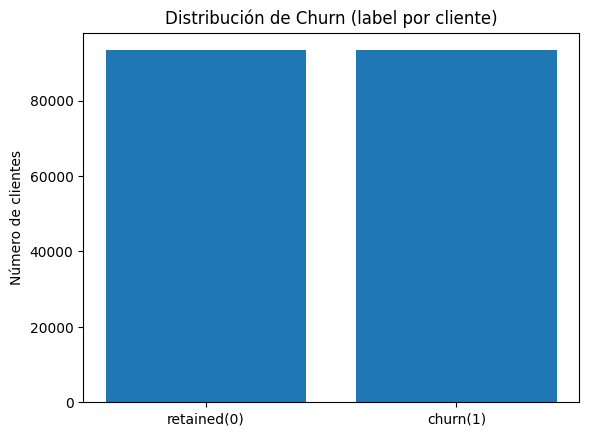

In [5]:
counts = last_purchase["churn_label"].value_counts().sort_index()

plt.figure()
plt.bar(["retained(0)", "churn(1)"], counts.values)
plt.title("Distribución de Churn (label por cliente)")
plt.ylabel("Número de clientes")
savefig("F01_churn_distribution.png")
plt.show()


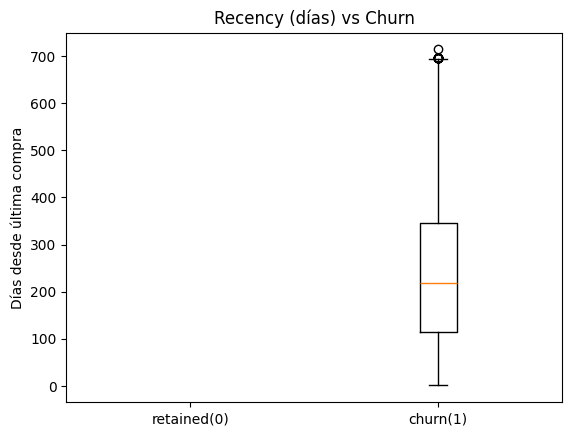

In [6]:
snapshot_date = df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = df.groupby("customer_unique_id").agg(
    recency_days=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("order_total", "sum"),
).reset_index()

rfm = rfm.merge(last_purchase[["customer_unique_id", "churn_label"]],
                on="customer_unique_id", how="left")

plt.figure()
plt.boxplot(
    [rfm.loc[rfm["churn_label"]==0, "recency_days"].dropna(),
     rfm.loc[rfm["churn_label"]==1, "recency_days"].dropna()],
    labels=["retained(0)", "churn(1)"]
)
plt.title("Recency (días) vs Churn")
plt.ylabel("Días desde última compra")
savefig("F02_recency_vs_churn.png")
plt.show()


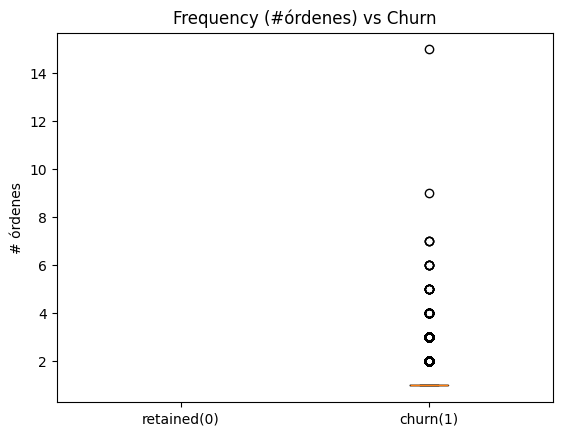

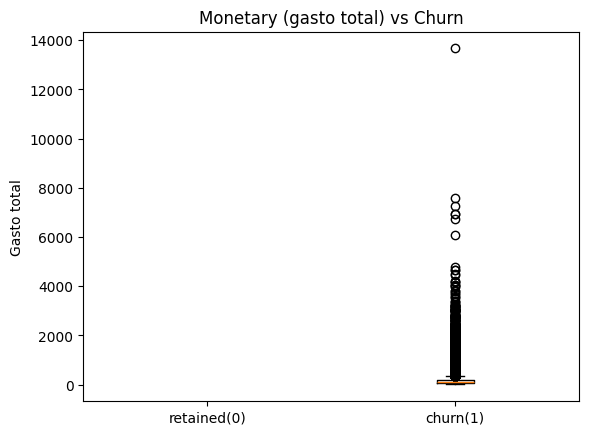

In [7]:
plt.figure()
plt.boxplot(
    [rfm.loc[rfm["churn_label"]==0, "frequency"].dropna(),
     rfm.loc[rfm["churn_label"]==1, "frequency"].dropna()],
    labels=["retained(0)", "churn(1)"]
)
plt.title("Frequency (#órdenes) vs Churn")
plt.ylabel("# órdenes")
savefig("F03A_frequency_vs_churn.png")
plt.show()

plt.figure()
plt.boxplot(
    [rfm.loc[rfm["churn_label"]==0, "monetary"].dropna(),
     rfm.loc[rfm["churn_label"]==1, "monetary"].dropna()],
    labels=["retained(0)", "churn(1)"]
)
plt.title("Monetary (gasto total) vs Churn")
plt.ylabel("Gasto total")
savefig("F03B_monetary_vs_churn.png")
plt.show()


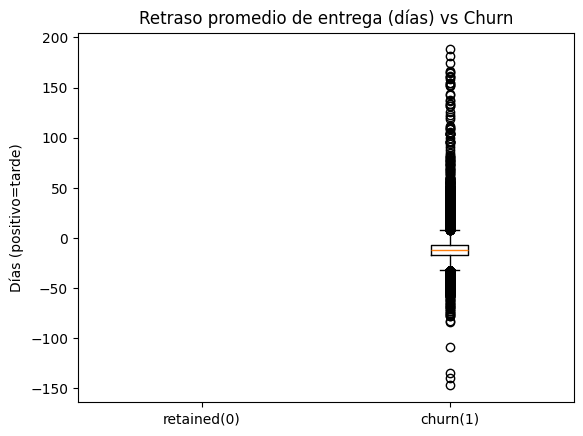

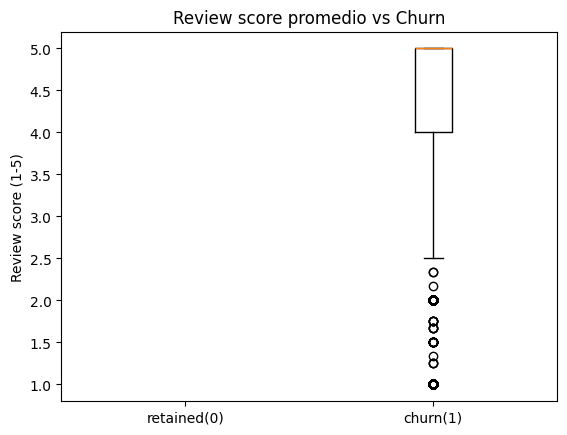

In [8]:
cust_log = df.groupby("customer_unique_id").agg(avg_delay=("delivery_delay_days", "mean")).reset_index()
cust_rev = df.groupby("customer_unique_id").agg(avg_review=("review_score", "mean")).reset_index()

tmp = (last_purchase[["customer_unique_id","churn_label"]]
       .merge(cust_log, on="customer_unique_id", how="left")
       .merge(cust_rev, on="customer_unique_id", how="left"))

plt.figure()
plt.boxplot(
    [tmp.loc[tmp["churn_label"]==0, "avg_delay"].dropna(),
     tmp.loc[tmp["churn_label"]==1, "avg_delay"].dropna()],
    labels=["retained(0)", "churn(1)"]
)
plt.title("Retraso promedio de entrega (días) vs Churn")
plt.ylabel("Días (positivo=tarde)")
savefig("F04_delay_vs_churn.png")
plt.show()

plt.figure()
plt.boxplot(
    [tmp.loc[tmp["churn_label"]==0, "avg_review"].dropna(),
     tmp.loc[tmp["churn_label"]==1, "avg_review"].dropna()],
    labels=["retained(0)", "churn(1)"]
)
plt.title("Review score promedio vs Churn")
plt.ylabel("Review score (1-5)")
savefig("F05_review_vs_churn.png")
plt.show()


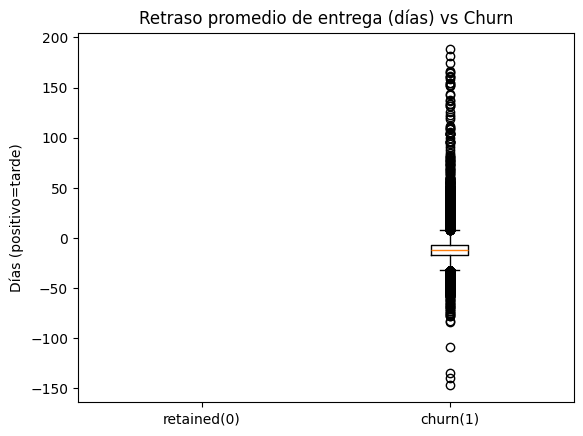

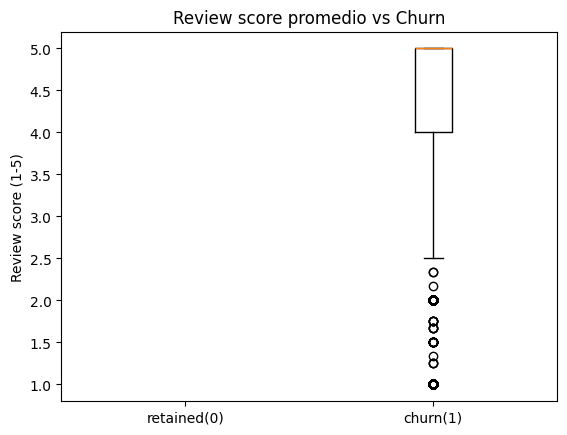

In [9]:
cust_log = df.groupby("customer_unique_id").agg(avg_delay=("delivery_delay_days", "mean")).reset_index()
cust_rev = df.groupby("customer_unique_id").agg(avg_review=("review_score", "mean")).reset_index()

tmp = (last_purchase[["customer_unique_id","churn_label"]]
       .merge(cust_log, on="customer_unique_id", how="left")
       .merge(cust_rev, on="customer_unique_id", how="left"))

plt.figure()
plt.boxplot(
    [tmp.loc[tmp["churn_label"]==0, "avg_delay"].dropna(),
     tmp.loc[tmp["churn_label"]==1, "avg_delay"].dropna()],
    labels=["retained(0)", "churn(1)"]
)
plt.title("Retraso promedio de entrega (días) vs Churn")
plt.ylabel("Días (positivo=tarde)")
savefig("F04_delay_vs_churn.png")
plt.show()

plt.figure()
plt.boxplot(
    [tmp.loc[tmp["churn_label"]==0, "avg_review"].dropna(),
     tmp.loc[tmp["churn_label"]==1, "avg_review"].dropna()],
    labels=["retained(0)", "churn(1)"]
)
plt.title("Review score promedio vs Churn")
plt.ylabel("Review score (1-5)")
savefig("F05_review_vs_churn.png")
plt.show()
